# Missing values and resampling

Allen Downey

Updated by [Tiniaco Leyba](https://tiniacoleyba.com/) in May 2025

[MIT License](https://en.wikipedia.org/wiki/MIT_License)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

## Missing value imputation

This notebook demonstrates a version of ["hot-deck" missing value imputation](https://en.wikipedia.org/wiki/Imputation_(statistics)).

First I'll load a dataset from the General Social Survey (GSS).

In [2]:
import os

datafile = '../data/gss.hdf5'
if not os.path.exists(datafile):
    !wget https://github.com/AllenDowney/ElementsOfDataScience/blob/v1/gss.hdf5

In [3]:
gss = pd.read_hdf(datafile, 'gss')
gss.shape

(62466, 10)

In [4]:
gss.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62466 entries, 0 to 62465
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     62466 non-null  int64  
 1   age      62281 non-null  float64
 2   cohort   62282 non-null  float64
 3   sex      62466 non-null  int64  
 4   race     62466 non-null  int64  
 5   educ     62304 non-null  float64
 6   realinc  55499 non-null  float64
 7   gunlaw   40550 non-null  float64
 8   grass    36222 non-null  float64
 9   wtssall  62466 non-null  float64
dtypes: float64(7), int64(3)
memory usage: 5.2 MB


It includes 62466 respondents and 10 variables for each respondent. The original dataset included 165 variables, we are working with a subset of the variables.

Suppose we want to run a model that compares income for men and women, controlling for age and education level.

Here's what it looks like if we don't fill missing data.

In [5]:
gss['age2'] = gss['age']**2
gss['educ2'] = gss['educ']**2

model = smf.ols('realinc ~ educ + educ2 + age + age2 + C(sex)', data=gss)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                realinc   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     2306.
Date:                Sat, 07 Jun 2025   Prob (F-statistic):               0.00
Time:                        09:14:17   Log-Likelihood:            -6.4504e+05
No. Observations:               55345   AIC:                         1.290e+06
Df Residuals:                   55339   BIC:                         1.290e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -2.237e+04   1498.239    -14.931      0.000   -2.53e+04   -1.94e+04
C(sex)[T.2] -4156.1139    238.319    -17.439      0.000   -4623.221   -3689.007
educ         -310.2474    185.958     -1.668      0.095    -674.726      54.232
educ2         150.5141      7.327     20.543      0.000     136.154     164.874
age          1703.0475     39.213     43.430      0.000    1626.189    1779.906
age2          -17.2387      0.403    -42.757      0.000     -18.029     -16.448
==============================================================================
Omnibus:                    17449.834   Durbin-Watson:                   1.978
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            51956.588
Skew:                           1.659   Prob(JB):                         0.00
Kurtosis:                       6.395   Cond. No.                     3.50e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.5e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Notice that the number of observations is 55345.  The model has quietly dropped respondents who are missing any of the independent variables or the dependent variable.

We can plot the results like this.

In [6]:
def plot_results(results):
    df = pd.DataFrame()
    df['age'] = np.linspace(18, 89)
    df['educ'] = 16

    df['age2'] = df['age']**2
    df['educ2'] = df['educ']**2

    df['sex'] = 1
    pred1 = results.predict(df)
    pred1.index = df['age']

    df['sex'] = 2
    pred2 = results.predict(df)
    pred2.index = df['age']
    
    pred1.plot(label='Male', alpha=0.6)
    pred2.plot(label='Female', alpha=0.6)

    plt.xlabel('Age')
    plt.ylabel('Real income (1986 $)')
    plt.title('Real income versus age, grouped by sex')
    plt.legend()

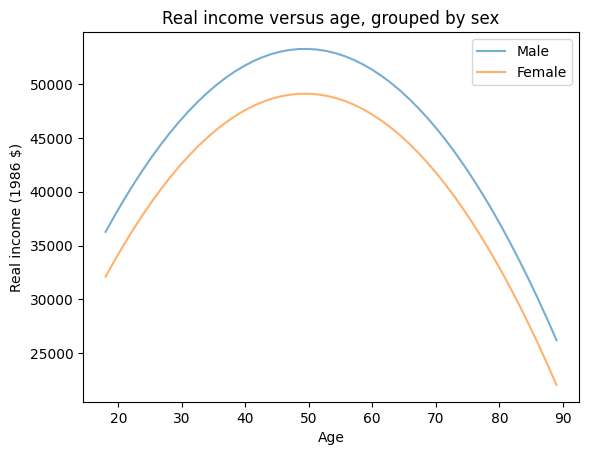

In [7]:
plot_results(results)

Let's see where those missing values are.

In [8]:
gss['age'].isna().sum()

np.int64(185)

There are 185 respondents with unknown age.

In [9]:
gss['educ'].isna().sum()

np.int64(162)

There are 162 respondents with unknown education level.

In [10]:
gss['sex'].isna().sum()

np.int64(0)

There are no respondents with unknown sex.

In [11]:
gss['realinc'].isna().sum()

np.int64(6967)

And there are 6967 respondents with unknown income.  So let's start filling things in.

The following function takes a Pandas Series and modifies it in place, replacing any NaN values with randomly-chosen valid values.

In [12]:
def fill_missing_values(series):
    """Fills missing values of the given Series.

    series: Pandas Series
    """
    # Boolean Series: true where values are missing
    null = series.isnull()

    # Series of valid values
    valid = series.dropna()
    
    # the fill values are a sample of the valid values 
    fill = valid.sample(null.sum(), replace=True)
    
    # we need the index of the fill values to line up
    # with the index of the DataFrame
    fill.index = series.index[null]

    # replace NaNs with the fill values
    series.fillna(fill, inplace=True)

Now, I will fill missing values for `age` and `educ`.

In [13]:
varnames = ['age', 'educ']
for varname in varnames:
    fill_missing_values(gss[varname])

And we can confirm that there are no NaNs left.

In [14]:
gss['age'].isna().sum()

np.int64(0)

In [15]:
gss['educ'].isna().sum()

np.int64(0)

I will not bother to fill `realinc` because it is the dependent variable.

Filling in the independent variables make it possible to include respondents with partial information, so it helps by adding information to the model.

Filling in the dependent variable would do nothing but add randomness to the results.  If the missing values introduce sampling bias (for example, if people with high income are less likely to respond), filling missing values would not help with that problem.

Now I'll run the model again with the filled data.

In [16]:
gss['age2'] = gss['age']**2
gss['educ2'] = gss['educ']**2

model2 = smf.ols('realinc ~ educ + educ2 + age + age2 + C(sex)', data=gss)
results2 = model2.fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                realinc   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     2305.
Date:                Sat, 07 Jun 2025   Prob (F-statistic):               0.00
Time:                        09:14:17   Log-Likelihood:            -6.4687e+05
No. Observations:               55499   AIC:                         1.294e+06
Df Residuals:                   55493   BIC:                         1.294e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -2.233e+04   1493.671    -14.950      0.000   -2.53e+04   -1.94e+04
C(sex)[T.2] -4172.3513    238.107    -17.523      0.000   -4639.042   -3705.660
educ         -312.0192    185.321     -1.684      0.092    -675.249      51.210
educ2         150.2813      7.304     20.575      0.000     135.965     164.597
age          1704.9849     39.174     43.524      0.000    1628.205    1781.765
age2          -17.2711      0.403    -42.886      0.000     -18.060     -16.482
==============================================================================
Omnibus:                    17525.705   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            52253.251
Skew:                           1.661   Prob(JB):                         0.00
Kurtosis:                       6.400   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

And plot the results.

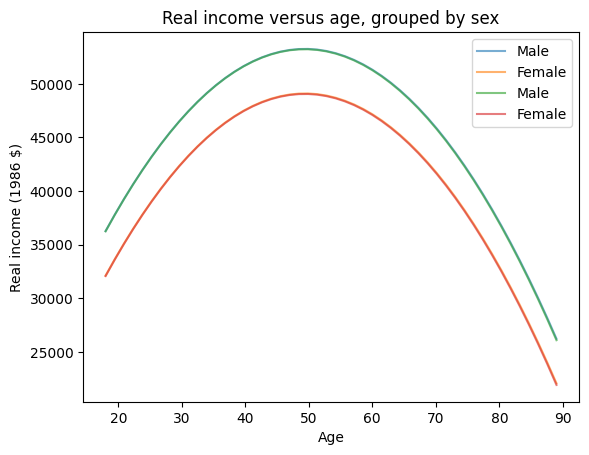

In [17]:
plot_results(results)
plot_results(results2)

There is no visible difference between the results with and without filling, which suggests that for this dataset missing data is not a substantial source of uncertainty.

If it were, I would consider other ways of imputing missing values, including [regression](https://en.wikipedia.org/wiki/Imputation_(statistics)#Regression).

## Resampling

Next we'll use resampling to quantify variability in the model due to random sampling.  The following function takes a DataFrame and resamples the rows.

In [18]:
def resample_rows_weighted(df, column):
    """Resamples a DataFrame using probabilities proportional to given column.

    df: DataFrame
    column: string column name to use as weights

    returns: DataFrame
    """
    weights = df[column]
    sample = df.sample(n=len(df), replace=True, weights=weights)
    return sample

The GSS uses stratified sampling, which means that some groups are deliberately oversampled.  The variable `wtssall` contains sampling weights, which we use during resampling to undersample the groups that were oversampled, and vice versa.

As a result, in the resampled dataset, every row has the same sampling weight; that is, the resampled dataset is representative of the population.

In the GSS dataset, the sampling weights are computed for each cycle of data collection, so I'll group the dataset by year, resample within each year, and then put the results back into one DataFrame.

In [19]:
def resample_by_year(df, column):
    """Resample rows within each year.

    df: DataFrame
    column: string name of weight variable

    returns DataFrame
    """
    grouped = df.groupby('year')
    samples = [resample_rows_weighted(group, column)
               for _, group in grouped]
    sample = pd.concat(samples, ignore_index=True)
    return sample

Here's how we use these functions:

In [20]:
gss = pd.read_hdf(datafile, 'gss')
sample = resample_by_year(gss, 'wtssall')

The following function takes a resampled dataset, runs the model, and returns the results.

In [21]:
def run_model(df):
    varnames = ['age', 'educ']
    for varname in varnames:
        fill_missing_values(df[varname])
    
    df['age2'] = df['age']**2
    df['educ2'] = df['educ']**2

    model = smf.ols('realinc ~ educ + educ2 + age + age2 + C(sex)', data=df)
    results = model.fit()
    return results

Here's how we can use it with one resampled dataset.

In [22]:
results3 = run_model(sample)
results3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                realinc   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     2043.
Date:                Sat, 07 Jun 2025   Prob (F-statistic):               0.00
Time:                        09:14:17   Log-Likelihood:            -6.4095e+05
No. Observations:               54786   AIC:                         1.282e+06
Df Residuals:                   54780   BIC:                         1.282e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -1.831e+04   1540.960    -11.881      0.000   -2.13e+04   -1.53e+04
C(sex)[T.2] -3834.6064    250.109    -15.332      0.000   -4324.822   -3344.390
educ         -116.1993    194.378     -0.598      0.550    -497.181     264.782
educ2         147.6316      7.718     19.129      0.000     132.505     162.758
age          1542.8734     41.119     37.522      0.000    1462.279    1623.468
age2          -15.6858      0.436    -36.014      0.000     -16.539     -14.832
==============================================================================
Omnibus:                    15636.633   Durbin-Watson:                   1.976
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            40480.781
Skew:                           1.561   Prob(JB):                         0.00
Kurtosis:                       5.827   Cond. No.                     3.26e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.26e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Now we can compare the results with the original and resampled datasets.

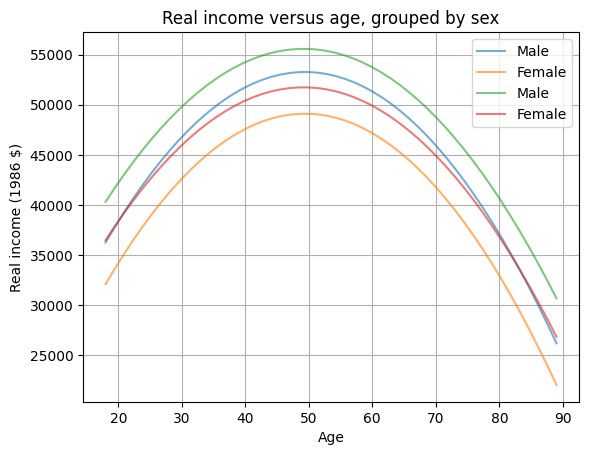

In [23]:
plot_results(results)
plot_results(results3)
plt.grid()
plt.show()

In this example, there is a substantial difference, which suggests that the groups that were oversampled tended to have lower incomes.  When we use resampling to correct for stratified sampling, predicted incomes increase.

## Confidence intervals

We can use repeated resampling to generate confidence intervals.  The following look resamples the dataset 11 times, runs the model, and collects the results.

In [24]:
result_seq = []
gss = pd.read_hdf(datafile, 'gss')

for i in range(11):
    sample = resample_by_year(gss, 'wtssall')
    results = run_model(sample)
    result_seq.append(results)

I'll use the following function to generate predictions for each resampled dataset.

In [25]:
def make_predict(results, sex):
    df = pd.DataFrame()
    df['age'] = np.linspace(18, 89)
    df['educ'] = 16

    df['age2'] = df['age']**2
    df['educ2'] = df['educ']**2

    df['sex'] = sex
    pred = results.predict(df)
    pred.index = df['age']
    return pred

A quick way to visualize variability due to sampling is to plot predictions for each of the resampled dataset using a low value of `alpha`.

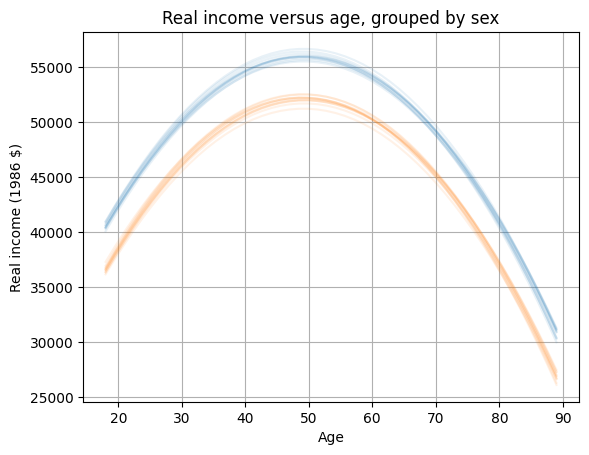

In [26]:
for results in result_seq:
    pred = make_predict(results, 1)
    pred.plot(color='C0', alpha=0.1)

for results in result_seq:
    pred = make_predict(results, 2)
    pred.plot(color='C1', alpha=0.1)
    
plt.xlabel('Age')
plt.ylabel('Real income (1986 $)')
plt.title('Real income versus age, grouped by sex')
plt.grid()
plt.show()

And alternative is to collect the predictions in a list:

In [27]:
result_seq = []
gss = pd.read_hdf(datafile, 'gss')

for i in range(51):
    sample = resample_by_year(gss, 'wtssall')
    results = run_model(sample)
    result_seq.append(results)

The result is a list of Series, but we can treat it as an array with one row for each resampled dataset and one column for each of the ages in the range.

Then we can use `np.percentiles` to compute the 5th, 50th, and 95th percentile in each columns (`axis=0` means we perform the computation along the first axis, which is down the columns).

The result is an array with 3 rows, which we can assign to variables.  Then we use `fill_between` to plot the area between the 5th and 95th percentiles, and `plot` to draw a line through the median values.

In [28]:
def plot_percentiles(result_seq, sex, **options):
    pred_list = []

    for results in result_seq:
        pred = make_predict(results, sex)
        pred_list.append(pred)

    low, med, high = np.percentile(pred_list, [5, 50, 95], axis=0)
    plt.fill_between(pred.index, low, high, alpha=0.3)
    plt.plot(pred.index, med, **options)

Here's what it looks like.

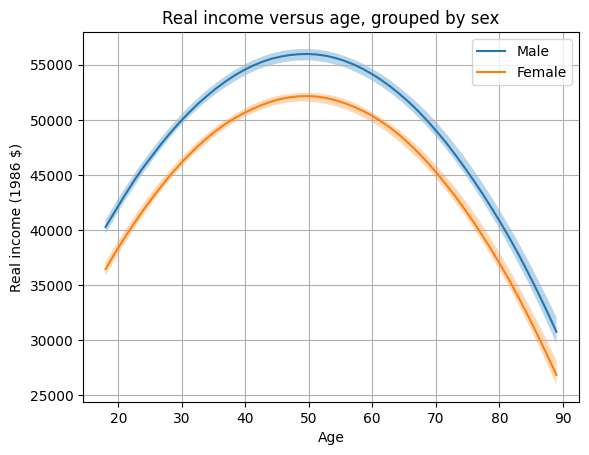

In [29]:
plot_percentiles(result_seq, 1, label='Male')
plot_percentiles(result_seq, 2, label='Female')

plt.xlabel('Age')
plt.ylabel('Real income (1986 $)')
plt.title('Real income versus age, grouped by sex')
plt.legend()
plt.grid()
plt.show()

The 90% confidence intervals are barely wider than the plotted lines, which suggests that random sampling is not a big source of uncertainty.

In summary, for this example:

1. Missing values are not a substantial source of uncertainty, so we could use a simple form of imputation, or (even simpler) drop rows with missing values.

2. Stratified sampling has a big effect on the results, so it is important to correct for it.

3. The confidence intervals show that random sampling contributes only small variations in the model's predictions.